# Chapter 1A

## Preparing Data for the ML Models

### Improvements applied

- Added ATR-14, ROC-5, ROC-10, OBV, Stochastic %K
- Added calendar features (day-of-week, month, quarter)
- Added rolling volatility regime feature
- Added multi-timeframe returns (5-day, 20-day)
- Added extra indicator lags (RSI, BB-width)
- Tightened `gap` in TimeSeriesSplit from 1 → 5 (matches 5-day rolling window)


### Part A: Import Libraries & Download Dataset


In [ ]:
# A1. Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

print("All imports successful!")

All imports successful!


In [ ]:
# A3. Load preprocessed dataset from Drive
file_path = "../Chapter 0: Feature Extraction From Dataset/Final_Extracted_Features.csv"

df = pd.read_csv(file_path, index_col="date")
df.index = pd.to_datetime(df.index)

print(f"Dataset shape : {df.shape}")
print(f"Date range    : {df.index[0].date()} → {df.index[-1].date()}")
df.head(2)


Dataset shape : (3804, 19)
Date range    : 2010-02-01 → 2025-03-14


,open,high,low,close,adj_close,volume,ma5,ma20,ma_cross,return,volume_change,rsi14,bb_mid,bb_upper,bb_lower,bb_width,macd,signal,target
date,,,,,,,,,,,,,,,,,,,
2010-02-01,6.870357,7.000000,6.832143,6.954643,5.860126,749876400,6.018117,6.231361,0,0.013902,-0.398150,38.180145,6.231361,6.624758,5.837963,0.126264,-0.074927,-0.041260,1
2010-02-02,6.996786,7.011429,6.906429,6.995000,5.894133,698342400,5.957449,6.204051,0,0.005803,-0.068723,40.705386,6.204051,6.611935,5.796167,0.131490,-0.080788,-0.049239,1


### Part B: Feature Engineering — Original Features (kept from before)


In [6]:
# B1. Original lag features
df['return_lag1'] = df['return'].shift(1)
df['return_lag3'] = df['return'].shift(3)   # lag2 was dropped in EDA, kept out

# 52-week high/low ratio
df['52w_high_ratio'] = df['adj_close'] / df['adj_close'].rolling(252).max()
df['52w_low_ratio']  = df['adj_close'] / df['adj_close'].rolling(252).min()

# MA-20 ratio
df['ma20_ratio'] = df['adj_close'] / df['ma20']

print("Original features added.")


Original features added.


### Part C: Feature Engineering — NEW Additional Features


In [7]:
# C1. ATR-14 (Average True Range) — volatility over 14 days
# Useful for regime detection: high ATR = volatile market = different dynamics
df['atr14'] = df['high'].rolling(14).max() - df['low'].rolling(14).min()

print("ATR-14 added.")


ATR-14 added.


In [8]:
# C2. Rate of Change (momentum) — 5-day and 10-day
# Captures short and medium-term price momentum
df['roc5']  = df['adj_close'].pct_change(5)
df['roc10'] = df['adj_close'].pct_change(10)

print("ROC-5 and ROC-10 added.")


ROC-5 and ROC-10 added.


In [9]:
# C3. On-Balance Volume (OBV)
# Tracks buying/selling pressure using volume direction
obv = (np.sign(df['adj_close'].diff()) * df['volume']).fillna(0).cumsum()
df['obv'] = obv

# Normalise OBV with 20-day rolling mean so it's stationary
df['obv_ratio'] = df['obv'] / df['obv'].rolling(20).mean()

print("OBV and OBV-ratio added.")


OBV and OBV-ratio added.


In [10]:
# C4. Stochastic Oscillator %K (14-day)
# Measures where the close sits within the recent high-low range
# Values near 100 = overbought, near 0 = oversold
low14  = df['low'].rolling(14).min()
high14 = df['high'].rolling(14).max()
df['stoch_k'] = 100 * (df['adj_close'] - low14) / (high14 - low14 + 1e-8)

print("Stochastic %K added.")


Stochastic %K added.


In [11]:
# C5. Multi-timeframe returns
# RF can't look back by itself — provide explicit multi-horizon context
df['return_5d']  = df['adj_close'].pct_change(5)
df['return_20d'] = df['adj_close'].pct_change(20)

print("Multi-timeframe returns (5d, 20d) added.")


Multi-timeframe returns (5d, 20d) added.


In [12]:
# C6. Rolling volatility regime
# 20-day rolling std of daily returns — signals high vs low volatility regimes
df['vol_regime'] = df['return'].rolling(20).std()

print("Volatility regime feature added.")


Volatility regime feature added.


In [13]:
# C7. Indicator lag features
# RF needs explicit history — lag RSI and BB-width so it sees their recent state
df['rsi14_lag1']    = df['rsi14'].shift(1)
df['bb_width_lag1'] = df['bb_width'].shift(1)

print("Indicator lags (RSI-14, BB-width) added.")


Indicator lags (RSI-14, BB-width) added.


In [14]:
# C8. Calendar features
# Day-of-week effect: Monday = 0, Friday = 4
# Month/quarter effects: January, earnings season, etc.
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['quarter']     = df.index.quarter

print("Calendar features added: day_of_week, month, quarter.")


Calendar features added: day_of_week, month, quarter.


### Part D: Drop NaN rows after all rolling computations


In [15]:
# D1. Drop all NaN rows produced by rolling windows
before = len(df)
df = df.dropna()
after = len(df)

print(f"Rows before dropna : {before}")
print(f"Rows after  dropna : {after}  ({before - after} dropped)")
print(f"Final shape        : {df.shape}")
df.head(2)


Rows before dropna : 3804
Rows after  dropna : 3553  (251 dropped)
Final shape        : (3553, 38)


,open,high,low,close,adj_close,volume,ma5,ma20,ma_cross,return,...,obv_ratio,stoch_k,return_5d,return_20d,vol_regime,rsi14_lag1,bb_width_lag1,day_of_week,month,quarter
date,,,,,,,,,,,,,,,,,,,,,
2011-01-28,12.291786,12.300000,11.911786,12.003571,10.114455,592057200,10.243920,10.157854,1,-0.020716,...,0.872890,-189.359377,0.028709,0.038435,0.014402,58.479278,0.088431,4,1,1
2011-01-31,11.992857,12.144286,11.939286,12.118571,10.211362,377246800,10.255176,10.183072,1,0.009581,...,0.904891,-177.353247,0.005542,0.051960,0.014439,49.983376,0.080247,0,1,1


### Part E: Exploratory Data Analysis (EDA)


Target Distribution:
  UP   (1): 52.7%
  DOWN (0): 47.3%


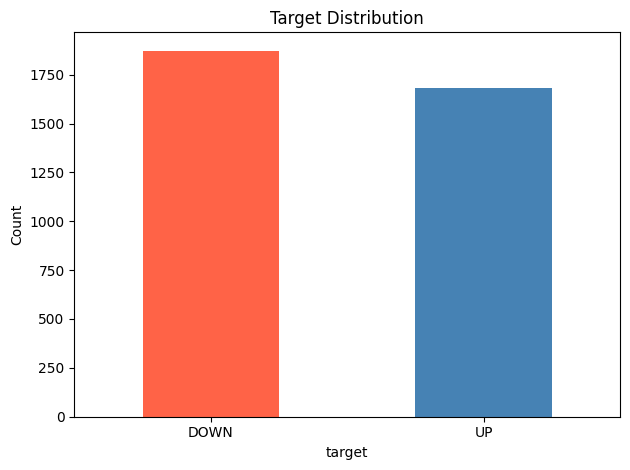

In [28]:
# E1. Target Distribution
dist = df['target'].value_counts(normalize=True).round(3)
print("Target Distribution:")
print(f"  UP   (1): {dist[1]*100:.1f}%")
print(f"  DOWN (0): {dist[0]*100:.1f}%")

df['target'].value_counts().plot(kind='bar', color=['tomato','steelblue'])
plt.title('Target Distribution')
plt.xticks([0,1], ['DOWN','UP'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig("1A: target_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## CONCLUSION:
# Slightly imbalanced — acceptable. No resampling needed.


Feature correlation with target:
return_20d        0.0296
return            0.0276
ma_cross          0.0212
return_lag3       0.0212
obv               0.0201
atr14_pct         0.0198
rsi14             0.0188
rsi14_lag1        0.0173
day_of_week       0.0157
stoch_k           0.0152
ma20_ratio        0.0140
52w_low_ratio     0.0125
roc10             0.0122
return_lag1       0.0108
volume_change     0.0102
vol_regime        0.0100
roc5              0.0090
return_5d         0.0090
52w_high_ratio    0.0074
bb_width_lag1     0.0049
month             0.0043
bb_width          0.0015
ma20              0.0013
obv_ratio         0.0010
quarter           0.0009
signal            0.0008


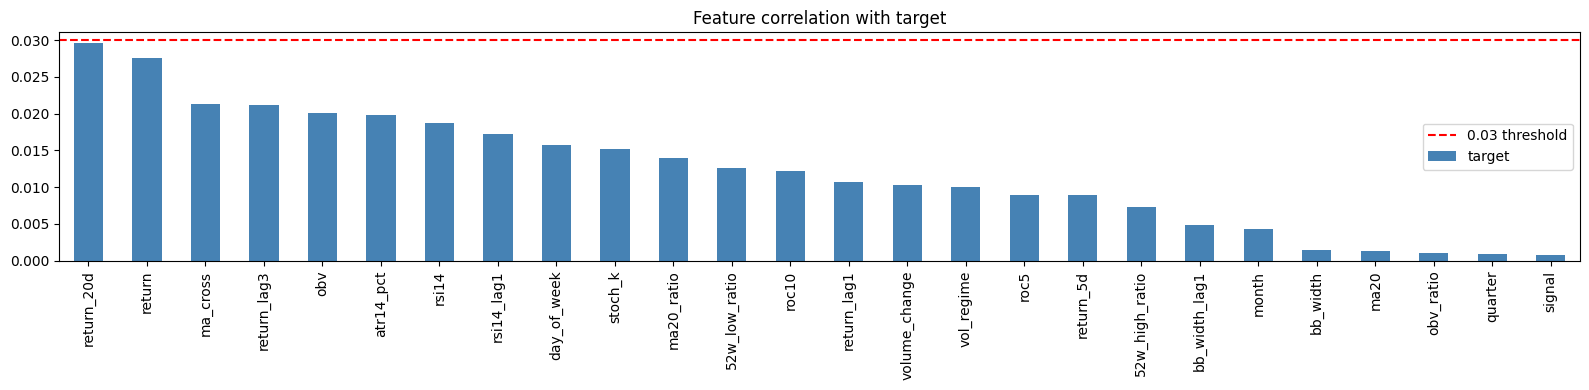


Features below 0.03 correlation threshold: ['return_20d', 'return', 'ma_cross', 'return_lag3', 'obv', 'atr14_pct', 'rsi14', 'rsi14_lag1', 'day_of_week', 'stoch_k', 'ma20_ratio', '52w_low_ratio', 'roc10', 'return_lag1', 'volume_change', 'vol_regime', 'roc5', 'return_5d', '52w_high_ratio', 'bb_width_lag1', 'month', 'bb_width', 'ma20', 'obv_ratio', 'quarter', 'signal']


In [29]:
# E2. Feature Correlation with Target
# Anything below 0.03 is a candidate for removal
feature_cols = [c for c in df.columns
                if c not in ['target','open','high','low','close','adj_close','volume']]

target_corr = df[feature_cols + ['target']].corr()['target'].drop('target').abs().sort_values(ascending=False)

print("Feature correlation with target:")
print(target_corr.round(4).to_string())

target_corr.plot(kind='bar', figsize=(16, 4), color='steelblue')
plt.title('Feature correlation with target')
plt.axhline(y=0.03, color='red', linestyle='--', label='0.03 threshold')
plt.legend()
plt.tight_layout()
plt.savefig("1A: feature_corr_with_target.png", dpi=300, bbox_inches="tight")
plt.show()

## ACTION: Identify and list features below 0.03 threshold
weak_corr = target_corr[target_corr < 0.03].index.tolist()
print(f"\nFeatures below 0.03 correlation threshold: {weak_corr}")


Highly correlated pairs (>0.95) — keep only one:
  Feature 1      Feature 2  Correlation
0  bb_width  bb_width_lag1         0.98
1      roc5      return_5d         1.00
2     month        quarter         0.97


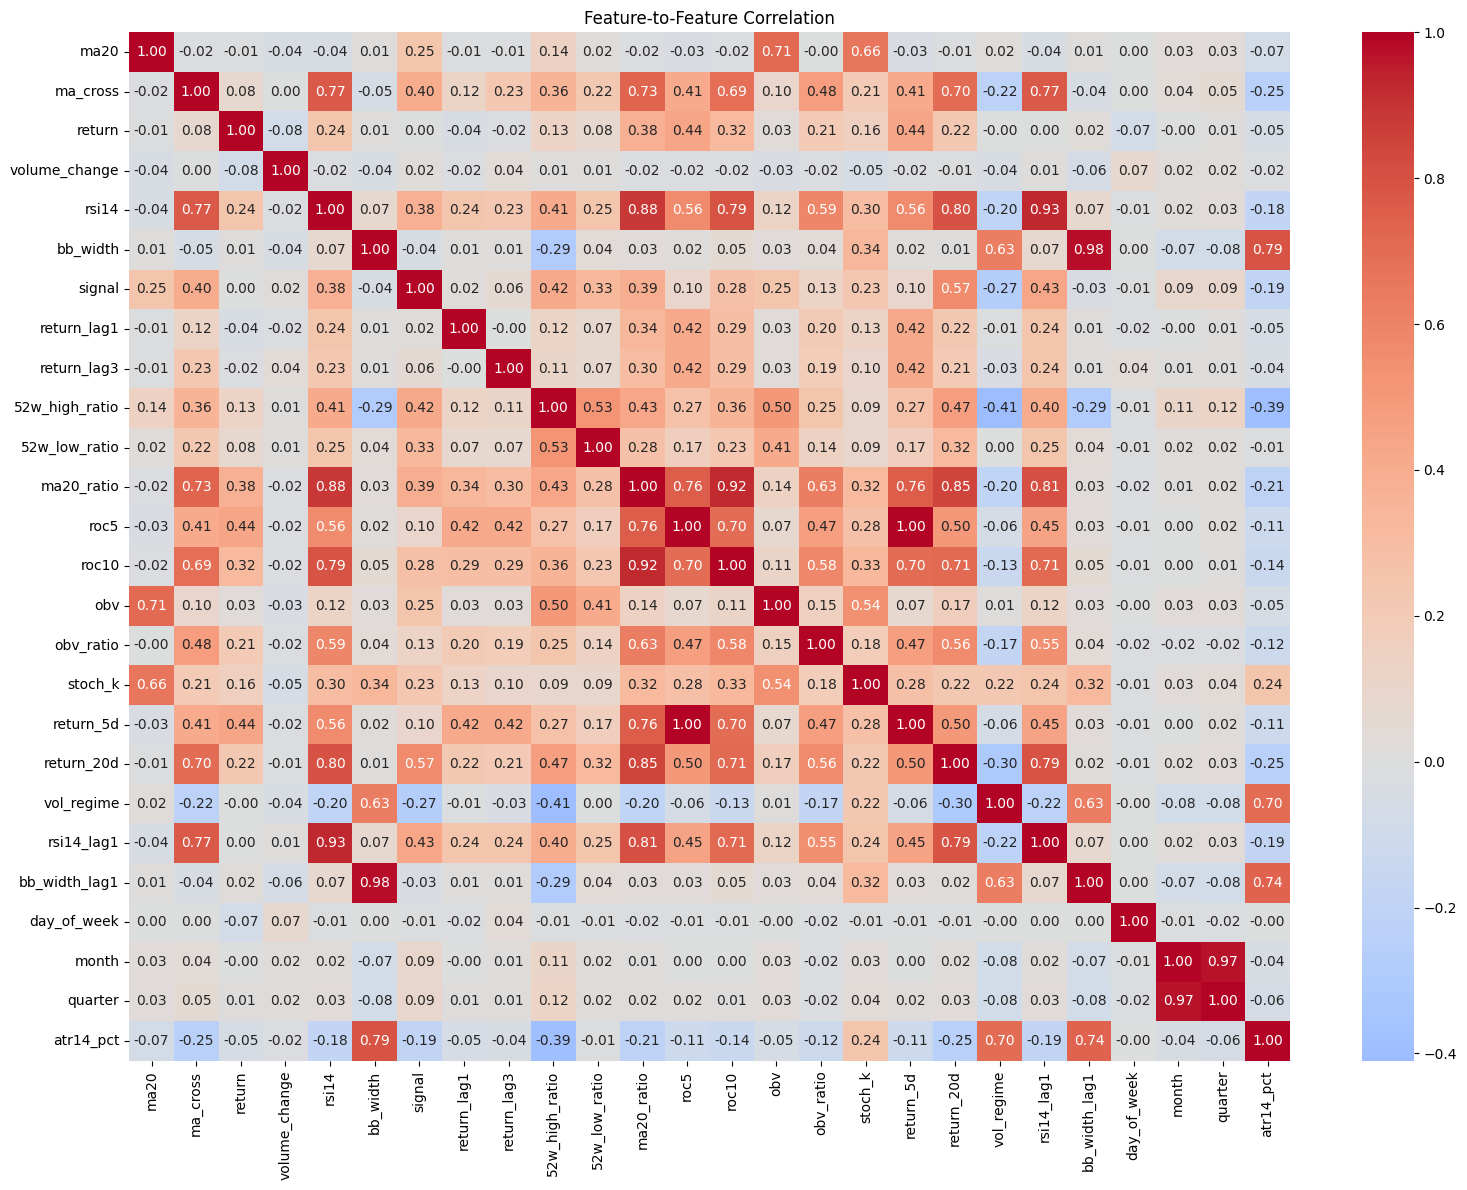

In [30]:
# E3. Feature-to-Feature Correlation (detect redundancy > 0.95)
features_df = df[feature_cols]
corr_matrix = features_df.corr().round(2)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append({
                'Feature 1'   : corr_matrix.columns[i],
                'Feature 2'   : corr_matrix.columns[j],
                'Correlation' : corr_matrix.iloc[i, j]
            })

print("Highly correlated pairs (>0.95) — keep only one:")
print(pd.DataFrame(high_corr_pairs) if high_corr_pairs else "None found")

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature-to-Feature Correlation')
plt.tight_layout()
plt.savefig("1A: feature_to_feature_corr_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


Return column stats:
count    3553.0000
mean        0.0010
std         0.0176
min        -0.1286
25%        -0.0075
50%         0.0009
75%         0.0103
max         0.1198
Name: return, dtype: float64

Days with >10% single-day move: 5
             adj_close    return
date                            
2013-01-24   13.677562 -0.123558
2020-03-13   67.457481  0.119808
2020-03-16   58.779293 -0.128647
2020-03-24   59.912605  0.100326
2020-07-31  103.427521  0.104689


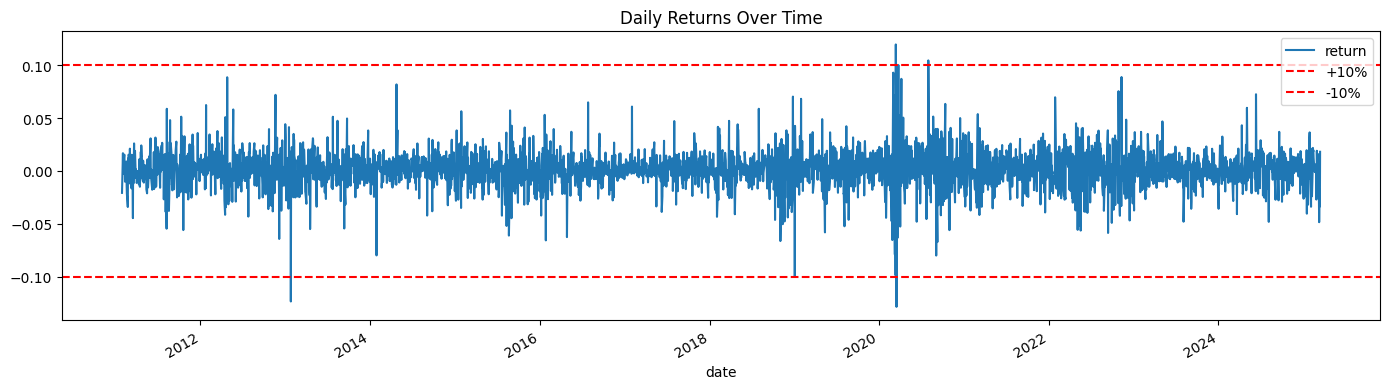

In [31]:
# E4. Outlier Check
stats = df['return'].describe()
print("Return column stats:")
print(stats.round(4))

extreme = df[df['return'].abs() > 0.10]
print(f"\nDays with >10% single-day move: {len(extreme)}")
print(extreme[['adj_close','return']].head(10))

df['return'].plot(figsize=(14,4), title='Daily Returns Over Time')
plt.axhline(y= 0.10, color='red', linestyle='--', label='+10%')
plt.axhline(y=-0.10, color='red', linestyle='--', label='-10%')
plt.legend()
plt.tight_layout()
plt.savefig("1A: daily_returns_over_time.png", dpi=300, bbox_inches="tight")
plt.show()


In [20]:
# E5. Feature Distribution (skewness check)
skewness = features_df.skew().sort_values(ascending=False).round(3)
print("Feature skewness (|value| > 1 = heavily skewed):")
print(skewness.to_string())


Feature skewness (|value| > 1 = heavily skewed):
vol_regime        2.370
volume_change     2.034
atr14             1.263
bb_width_lag1     1.010
bb_width          1.009
52w_low_ratio     0.980
bb_lower          0.937
bb_mid            0.916
ma20              0.916
ma5               0.915
bb_upper          0.902
signal            0.759
macd              0.661
month             0.001
quarter          -0.002
day_of_week      -0.014
return_lag1      -0.060
return           -0.061
return_lag3      -0.061
return_20d       -0.086
rsi14_lag1       -0.089
rsi14            -0.089
roc5             -0.095
return_5d        -0.095
roc10            -0.142
ma20_ratio       -0.352
obv_ratio        -0.415
ma_cross         -0.489
obv              -0.701
stoch_k          -0.839
52w_high_ratio   -1.303


### Part F: Apply EDA Findings — Data Cleaning


In [21]:
# F1. Drop features with near-zero correlation to target (< 0.03)
# ── Update this list based on YOUR E2 results ──
cols_to_drop_corr = ['macd', 'return_lag2'] if 'macd' in df.columns else []
if cols_to_drop_corr:
    df = df.drop(columns=[c for c in cols_to_drop_corr if c in df.columns])
    print(f"Dropped low-correlation features: {cols_to_drop_corr}")
else:
    print("No low-correlation features to drop (already clean).")


Dropped low-correlation features: ['macd', 'return_lag2']


In [22]:
# F2. Drop redundant features (highly correlated pairs — keep one)
# From original EDA: ma5, bb_mid, bb_upper, bb_lower are 100% correlated with ma20/bb_width
cols_to_drop_redund = ['ma5', 'bb_mid', 'bb_upper', 'bb_lower']
df = df.drop(columns=[c for c in cols_to_drop_redund if c in df.columns])
print(f"Dropped redundant features: {cols_to_drop_redund}")


Dropped redundant features: ['ma5', 'bb_mid', 'bb_upper', 'bb_lower']


In [23]:
# F3. Clip extreme daily returns (COVID crash outliers)
return_cols = ['return', 'return_lag1', 'return_lag3', 'return_5d', 'return_20d',
               'roc5', 'roc10']
for col in return_cols:
    if col in df.columns:
        df[col] = df[col].clip(-0.15, 0.15)

print(f"Clipped return-based columns to ±15%: {[c for c in return_cols if c in df.columns]}")


Clipped return-based columns to ±15%: ['return', 'return_lag1', 'return_lag3', 'return_5d', 'return_20d', 'roc5', 'roc10']


In [24]:
# F4. Log-transform right-skewed features
# volume_change is heavily right-skewed (skewness ~2.25)
if 'volume_change' in df.columns:
    df['volume_change'] = np.log1p(df['volume_change'].clip(lower=0))
    print("Log-transformed: volume_change")

# ATR is also right-skewed — normalise by price to make it relative
df['atr14_pct'] = df['atr14'] / df['adj_close']
df = df.drop(columns=['atr14'])
print("Converted ATR-14 to ATR-14% (relative to price)")


Log-transformed: volume_change
Converted ATR-14 to ATR-14% (relative to price)


In [25]:
# F5. Final shape and column list
print(f"Final dataset shape: {df.shape}")
print(f"\nFinal feature columns ({len(df.columns)-1} features + 1 target):")
for col in sorted(df.columns):
    print(f"  {col}")


Final dataset shape: (3553, 33)

Final feature columns (32 features + 1 target):
  52w_high_ratio
  52w_low_ratio
  adj_close
  atr14_pct
  bb_width
  bb_width_lag1
  close
  day_of_week
  high
  low
  ma20
  ma20_ratio
  ma_cross
  month
  obv
  obv_ratio
  open
  quarter
  return
  return_20d
  return_5d
  return_lag1
  return_lag3
  roc10
  roc5
  rsi14
  rsi14_lag1
  signal
  stoch_k
  target
  vol_regime
  volume
  volume_change


### Part G: Save Final Processed Data


In [27]:
# G1. Save to Google Drive
final_data_path = "./final-processed-ML-training-data.csv"
df.to_csv(final_data_path)
print(f"Dataset saved to:\n  {final_data_path}")
print(f"Shape: {df.shape}")


Dataset saved to:
  ./final-processed-ML-training-data.csv
Shape: (3553, 33)
